In [1]:
import pandas as pd

df1 = pd.read_csv('SKW_final_w_Pd.csv')

print("DataFrame Head:")
display(df1.head())

print("\nDataFrame Info:")
display(df1.info())

DataFrame Head:


,Location,UWI,Reading Time,Average Amps (A) (Raw),Drive Frequency (Hz) (Raw),Intake Pressure (psi) (Raw),Discharge Pressure (psi) (Raw),Intake Temperature (F) (Raw),Motor Temperature (F) (Raw),Vibration (gravit) (Raw),Virtual Rate (BFPD) (Raw)
0,SKW-14,SKW-14,2025-06-23 17:20:00,0.0,0.0,0.0,0.0,32.0,32.0,0.000000,0.0
1,SKW-14,SKW-14,2025-06-23 17:30:00,0.0,0.0,0.0,0.0,32.0,32.0,0.000000,0.0
2,SKW-14,SKW-14,2025-06-23 17:40:00,0.0,0.0,0.0,0.0,32.0,32.0,0.000000,0.0
3,SKW-14,SKW-14,2025-06-23 18:10:00,0.0,0.0,2104.7,2104.4,197.0,192.0,0.041808,0.0
4,SKW-14,SKW-14,2025-06-23 18:20:00,0.0,0.0,2104.0,2104.5,197.8,192.8,0.041808,0.0



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9293 entries, 0 to 9292
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Location                        9293 non-null   object 
 1   UWI                             9293 non-null   object 
 2   Reading Time                    9293 non-null   object 
 3   Average Amps (A) (Raw)          9293 non-null   float64
 4   Drive Frequency (Hz) (Raw)      9293 non-null   float64
 5   Intake Pressure (psi) (Raw)     9293 non-null   float64
 6   Discharge Pressure (psi) (Raw)  9293 non-null   float64
 7   Intake Temperature (F) (Raw)    9293 non-null   float64
 8   Motor Temperature (F) (Raw)     9293 non-null   float64
 9   Vibration (gravit) (Raw)        9293 non-null   float64
 10  Virtual Rate (BFPD) (Raw)       9293 non-null   float64
dtypes: float64(8), object(3)
memory usage: 798.7+ KB


None

In [2]:
df = df1.drop(df1.columns[4], axis=1)

In [3]:
df['Reading Time'] = pd.to_datetime(df['Reading Time'])
df = df.sort_values(by='Reading Time')
display(df.head())

,Location,UWI,Reading Time,Average Amps (A) (Raw),Intake Pressure (psi) (Raw),Discharge Pressure (psi) (Raw),Intake Temperature (F) (Raw),Motor Temperature (F) (Raw),Vibration (gravit) (Raw),Virtual Rate (BFPD) (Raw)
0,SKW-14,SKW-14,2025-06-23 17:20:00,0.0,0.0,0.0,32.0,32.0,0.000000,0.0
1,SKW-14,SKW-14,2025-06-23 17:30:00,0.0,0.0,0.0,32.0,32.0,0.000000,0.0
2,SKW-14,SKW-14,2025-06-23 17:40:00,0.0,0.0,0.0,32.0,32.0,0.000000,0.0
3,SKW-14,SKW-14,2025-06-23 18:10:00,0.0,2104.7,2104.4,197.0,192.0,0.041808,0.0
4,SKW-14,SKW-14,2025-06-23 18:20:00,0.0,2104.0,2104.5,197.8,192.8,0.041808,0.0


In [4]:
import numpy as np
from scipy.stats import linregress

# --- sort dataframe ---
df = df.sort_values('Reading Time').reset_index(drop=True)

# --- tentukan interval waktu (30 menit) ---
time_interval = pd.Timedelta(minutes=30)

# snap waktu awal & akhir ke kelipatan 30 menit
start_time = df['Reading Time'].iloc[0].floor('30min')
end_time = df['Reading Time'].iloc[-1].ceil('30min')

# buat daftar window tiap 30 menit
time_windows = pd.date_range(start=start_time, end=end_time, freq='30min')

# --- hitung slope ---
slopes_list = []

for window_start in time_windows:
    window_end = window_start + time_interval
    window_df = df[(df['Reading Time'] >= window_start) & (df['Reading Time'] < window_end)]

    # skip kalau data terlalu sedikit
    if len(window_df) < 2:
        continue

    # ambil kolom numerik
    numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
    cols_to_exclude = ['Discharge Pressure (psi) (Raw)']  # contoh kalau mau dikecualikan
    # numerical_cols = [col for col in numerical_cols if col not in cols_to_exclude]

    # hitung slope per kolom
    window_slopes = {}
    for col in numerical_cols:
        temp_df = window_df[['Reading Time', col]].dropna()
        if len(temp_df) > 1:
            temp_time_diff = (temp_df['Reading Time'] - window_start).dt.total_seconds().values
            slope, _, _, _, _ = linregress(temp_time_diff, temp_df[col])
            window_slopes[col + '_slope'] = slope
        else:
            window_slopes[col + '_slope'] = np.nan

    # simpan waktu window
    window_slopes['Window_Start_Time'] = window_start
    slopes_list.append(window_slopes)

# --- konversi ke DataFrame ---
slopes_df = pd.DataFrame(slopes_list)

# jadikan Window_Start_Time sebagai index
slopes_df = slopes_df.set_index('Window_Start_Time')


In [5]:
# from scipy.stats import linregress
# import numpy as np


# # Tentukan interval waktu (30 menit)
# time_interval = pd.Timedelta(hours=0.5)

# # Urutkan DataFrame berdasarkan waktu
# df = df.sort_values('Reading Time').reset_index(drop=True)

# # Buat list semua titik waktu awal yang kelipatan 30 menit dari waktu awal
# start_time = df['Reading Time'].iloc[0]
# end_time = df['Reading Time'].iloc[-1]
# time_windows = pd.date_range(start=start_time, end=end_time, freq='0.5H')

# # Inisialisasi list untuk menyimpan hasil slope
# slopes_list = []

# # Iterasi setiap window waktu
# for window_start in time_windows:
#     window_end = window_start + time_interval
#     window_df = df[(df['Reading Time'] >= window_start) & (df['Reading Time'] < window_end)]

#     # Lewati window jika datanya terlalu sedikit
#     if len(window_df) < 2:
#         continue

#     # Ekstrak kolom numerik
#     numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
#     cols_to_exclude = ['Discharge Pressure (psi) (Raw)']  # jika ingin mengecualikan
#     # numerical_cols = [col for col in numerical_cols if col not in cols_to_exclude]

#     # Hitung slope tiap kolom numerik
#     window_slopes = {}
#     for col in numerical_cols:
#         temp_df = window_df[[col, 'Reading Time']].dropna()
#         if len(temp_df) > 1:
#             temp_time_diff = (temp_df['Reading Time'] - window_start).dt.total_seconds().values
#             slope, _, _, _, _ = linregress(temp_time_diff, temp_df[col])
#             window_slopes[col + '_slope'] = slope
#         else:
#             window_slopes[col + '_slope'] = np.nan

#     window_slopes['Window_Start_Time'] = window_start
#     slopes_list.append(window_slopes)

# # Konversi ke DataFrame
# slopes_df = pd.DataFrame(slopes_list)

# display(slopes_df.head())

In [6]:
# Buat salinan daftar nama kolom
cols1 = slopes_df.columns.tolist()

cols1[0] = 'A'
cols1[1] = 'IP'
cols1[2] = 'DP'   
cols1[3] = 'IT'   
cols1[4] = 'MT'   
cols1[5] = 'V'   
cols1[6] = 'R'

# Terapkan kembali ke dataframe
slopes_df.columns = cols1

In [7]:
df

,Location,UWI,Reading Time,Average Amps (A) (Raw),Intake Pressure (psi) (Raw),Discharge Pressure (psi) (Raw),Intake Temperature (F) (Raw),Motor Temperature (F) (Raw),Vibration (gravit) (Raw),Virtual Rate (BFPD) (Raw)
0,SKW-14,SKW-14,2025-06-23 17:20:00,0.0,0.0,0.0,32.0,32.0,0.000000,0.000000
1,SKW-14,SKW-14,2025-06-23 17:30:00,0.0,0.0,0.0,32.0,32.0,0.000000,0.000000
2,SKW-14,SKW-14,2025-06-23 17:40:00,0.0,0.0,0.0,32.0,32.0,0.000000,0.000000
3,SKW-14,SKW-14,2025-06-23 18:10:00,0.0,2104.7,2104.4,197.0,192.0,0.041808,0.000000
4,SKW-14,SKW-14,2025-06-23 18:20:00,0.0,2104.0,2104.5,197.8,192.8,0.041808,0.000000
...,...,...,...,...,...,...,...,...,...,...
9288,SKW-14,SKW-14,2025-07-31 23:20:00,31.1,2023.5,2023.2,269.1,264.9,0.042828,4589.635881
9289,SKW-14,SKW-14,2025-07-31 23:30:00,31.2,2023.5,2023.2,269.1,264.9,0.042828,4462.820143
9290,SKW-14,SKW-14,2025-07-31 23:40:00,31.2,2023.5,2023.2,269.1,264.9,0.042828,4462.820143
9291,SKW-14,SKW-14,2025-07-31 23:50:00,31.2,2023.5,2023.2,269.1,264.9,0.042828,4462.820143


In [8]:
# # Pastikan kolom Reading Time sudah datetime
# df1["Reading Time"] = pd.to_datetime(df1["Reading Time"])

# # Tentukan start time dari data pertama
# start_time = df1["Reading Time"].min()

# # Set index menjadi Reading Time
# df_resampled = (
#     df1.set_index("Reading Time")
#        .resample("30T", origin=start_time)
#        .mean(numeric_only=True)
#        .reset_index()
# )
# Pastikan kolom Reading Time sudah datetime
df1["Reading Time"] = pd.to_datetime(df1["Reading Time"])

# Resample ke setiap 30 menit, align ke 00 dan 30 menit
df_resampled = (
    df1.set_index("Reading Time")
       .resample("30T", origin="epoch")   # align ke 00, 30
       .mean(numeric_only=True)
       .reset_index()
)

In [9]:
df_resampled.head()

,Reading Time,Average Amps (A) (Raw),Drive Frequency (Hz) (Raw),Intake Pressure (psi) (Raw),Discharge Pressure (psi) (Raw),Intake Temperature (F) (Raw),Motor Temperature (F) (Raw),Vibration (gravit) (Raw),Virtual Rate (BFPD) (Raw)
0,2025-06-23 17:00:00,0.000000,0.000000,0.000000,0.000000,32.000000,32.000000,0.000000,0.000000
1,2025-06-23 17:30:00,0.000000,0.000000,0.000000,0.000000,32.000000,32.000000,0.000000,0.000000
2,2025-06-23 18:00:00,0.000000,0.000000,2104.350000,2104.450000,197.400000,192.400000,0.041808,0.000000
3,2025-06-23 18:30:00,8.933333,13.333333,2106.266667,2179.633333,198.933333,199.666667,0.041468,1566.632162
4,2025-06-23 19:00:00,10.333333,13.333333,2082.433333,2414.733333,201.933333,233.433333,0.041808,1207.330135


In [10]:
slopes_df.head()

,A,IP,DP,IT,MT,V,R
Window_Start_Time,,,,,,,
2025-06-23 17:30:00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00
2025-06-23 18:00:00,0.000000e+00,-0.001167,0.000167,0.001333,0.001333,0.000000e+00,0.000000e+00
2025-06-23 18:30:00,2.233333e-02,0.005667,0.187750,0.001250,0.015583,-8.497635e-07,3.916580e+00
2025-06-23 19:00:00,-4.934325e-19,-0.040167,0.428500,0.004167,0.022583,0.000000e+00,1.263187e-17
2025-06-23 19:30:00,1.840852e-03,-0.040835,0.044915,0.007345,0.037556,-6.389199e-07,-6.937044e-01


In [11]:
slopes_df = slopes_df.reset_index()
X_predict = slopes_df.drop(columns=['Window_Start_Time'])

# Display the head of the feature matrix
display(X_predict.head())

,A,IP,DP,IT,MT,V,R
0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00
1,0.000000e+00,-0.001167,0.000167,0.001333,0.001333,0.000000e+00,0.000000e+00
2,2.233333e-02,0.005667,0.187750,0.001250,0.015583,-8.497635e-07,3.916580e+00
3,-4.934325e-19,-0.040167,0.428500,0.004167,0.022583,0.000000e+00,1.263187e-17
4,1.840852e-03,-0.040835,0.044915,0.007345,0.037556,-6.389199e-07,-6.937044e-01


In [12]:
slopes_df.to_csv('slopes_df_30menit.csv', index=False)
X_predict.to_csv('X_predict_30menit.csv', index=False)
df_resampled.to_csv('df_all.csv', index=False)

# Tampilan

In [13]:
import matplotlib.pyplot as plt

C:\Users\Azhar Nurzaman\AppData\Local\Temp\ipykernel_33208\842737232.py:2: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  time = slopes_df['Window_Start_Time'].dt.to_pydatetime()


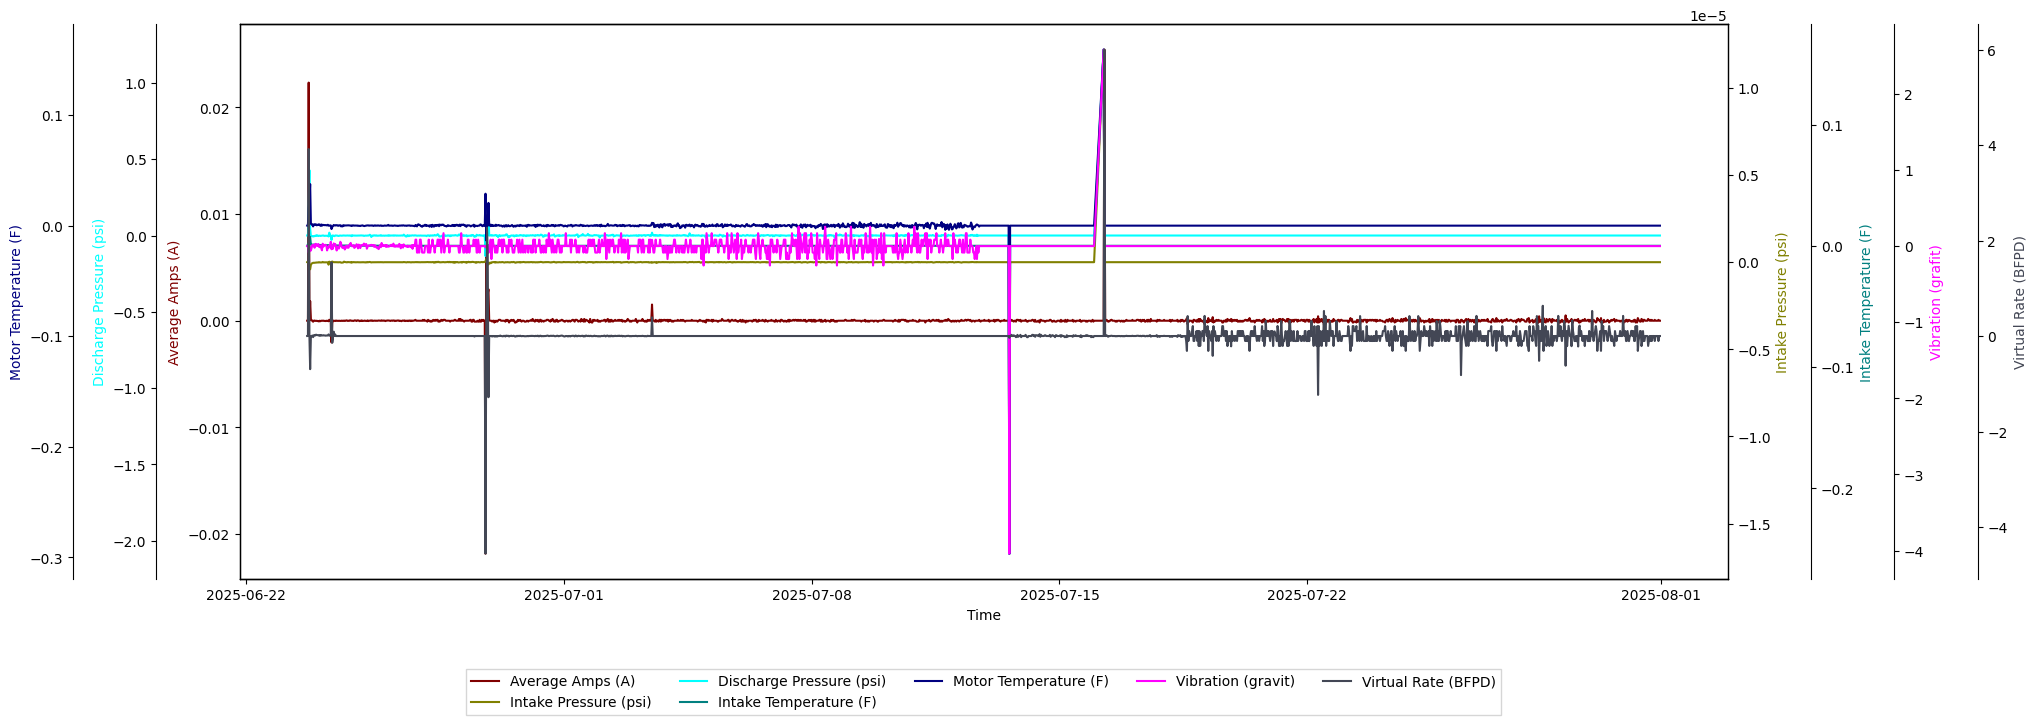

In [14]:
# kalau mau langsung simpan ke variable "time"
time = slopes_df['Window_Start_Time'].dt.to_pydatetime()

ready = slopes_df

fig = plt.figure()
host = fig.add_subplot(111)

par1 = host.twinx()
par2 = host.twinx()
par3 = host.twinx()
par4 = host.twinx()
par5 = host.twinx()
par6 = host.twinx()

host.set_xlabel("Time")
host.set_ylabel("Average Amps (A)")
par1.set_ylabel("Intake Pressure (psi)")
par2.set_ylabel("Discharge Pressure (psi)")
par3.set_ylabel("Intake Temperature (F)")
par4.set_ylabel("Motor Temperature (F)")
par5.set_ylabel("Vibration (grafit)")
par6.set_ylabel("Virtual Rate (BFPD)")

p1, = host.plot(time, ready["A"].to_numpy(), color='#800000', label="Average Amps (A)")
p2, = par1.plot(time, ready["IP"].to_numpy(), color='#808000', label="Intake Pressure (psi)")
p3, = par2.plot(time, ready["DP"].to_numpy(), color='#00ffff', label="Discharge Pressure (psi)")
p4, = par3.plot(time, ready["IT"].to_numpy(), color='#018080', label="Intake Temperature (F)")
p5, = par4.plot(time, ready["MT"].to_numpy(), color='#000080', label="Motor Temperature (F)")
p6, = par5.plot(time, ready["V"].to_numpy(), color='#ff00ff', label="Vibration (gravit)")
p7, = par6.plot(time, ready["R"].to_numpy(), color='#434755', label="Virtual Rate (BFPD)")

# Shrink current axis's height by 10% on the bottom
box = host.get_position()
host.set_position([box.x0, box.y0, box.width * 3, box.height * 1.5])

# Put a legend below current axis
lns = [p1, p2, p3, p4, p5, p6, p7]
host.legend(handles=lns, loc='upper center', bbox_to_anchor=(0.5, -0.15),
          fancybox=False, shadow=False, ncol=5)

#Spines
par2.spines['left'].set_position(('outward', 60))
par3.spines['right'].set_position(('outward', 60))
par4.spines['left'].set_position(('outward', 120))
par5.spines['right'].set_position(('outward', 120))
par6.spines['right'].set_position(('outward', 180))

#Ticks
par2.yaxis.set_ticks_position('left')
par3.yaxis.set_ticks_position('right')
par4.yaxis.set_ticks_position('left')
par5.yaxis.set_ticks_position('right')
par6.yaxis.set_ticks_position('right')

#Label
par2.yaxis.set_label_position('left')
par3.yaxis.set_label_position('right')
par4.yaxis.set_label_position('left')
par5.yaxis.set_label_position('right')
par6.yaxis.set_label_position('right')

#Label's color
host.yaxis.label.set_color(p1.get_color())
par1.yaxis.label.set_color(p2.get_color())
par2.yaxis.label.set_color(p3.get_color())
par3.yaxis.label.set_color(p4.get_color())
par4.yaxis.label.set_color(p5.get_color())
par5.yaxis.label.set_color(p6.get_color())
par6.yaxis.label.set_color(p7.get_color())

plt.show()